  CustomerID RegistrationDate   Age             Gender IncomeLevel    Country  \
0        NaN       2020-05-10  25.0                NaN         NaN      Other   
1  CUST00002       2021-07-18   NaN  Prefer not to say        High    Germany   
2  CUST00003       2021-02-04  43.0                NaN        High     France   
3  CUST00004       2020-12-31  49.0             Female        High  Australia   
4  CUST00005       2022-06-27  29.0             Female   Very High  Australia   

          City  TotalPurchases  AverageOrderValue  CustomerLifetimeValue  ...  \
0        Tokyo             4.0          15.886509                    NaN  ...   
1       London             6.0          27.638853             181.725056  ...   
2          NaN            10.0         161.739425            1810.555150  ...   
3  Los Angeles             5.0          14.194263              86.219740  ...   
4        Tokyo             7.0       31147.427206            2112.575945  ...   

  SocialMediaEngagementRat

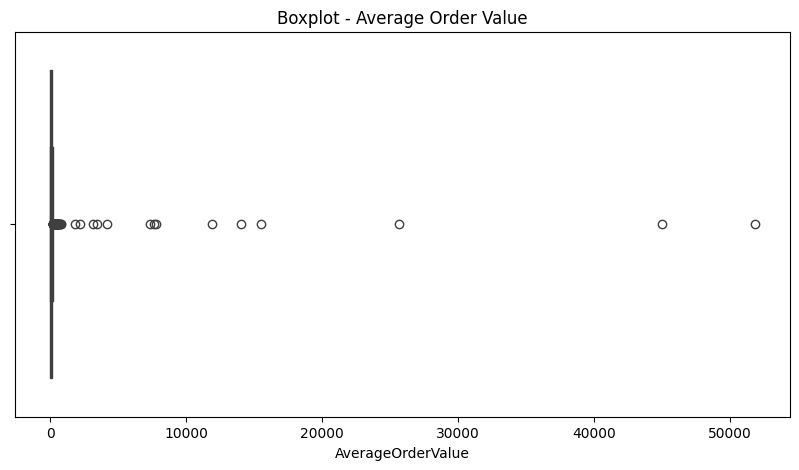

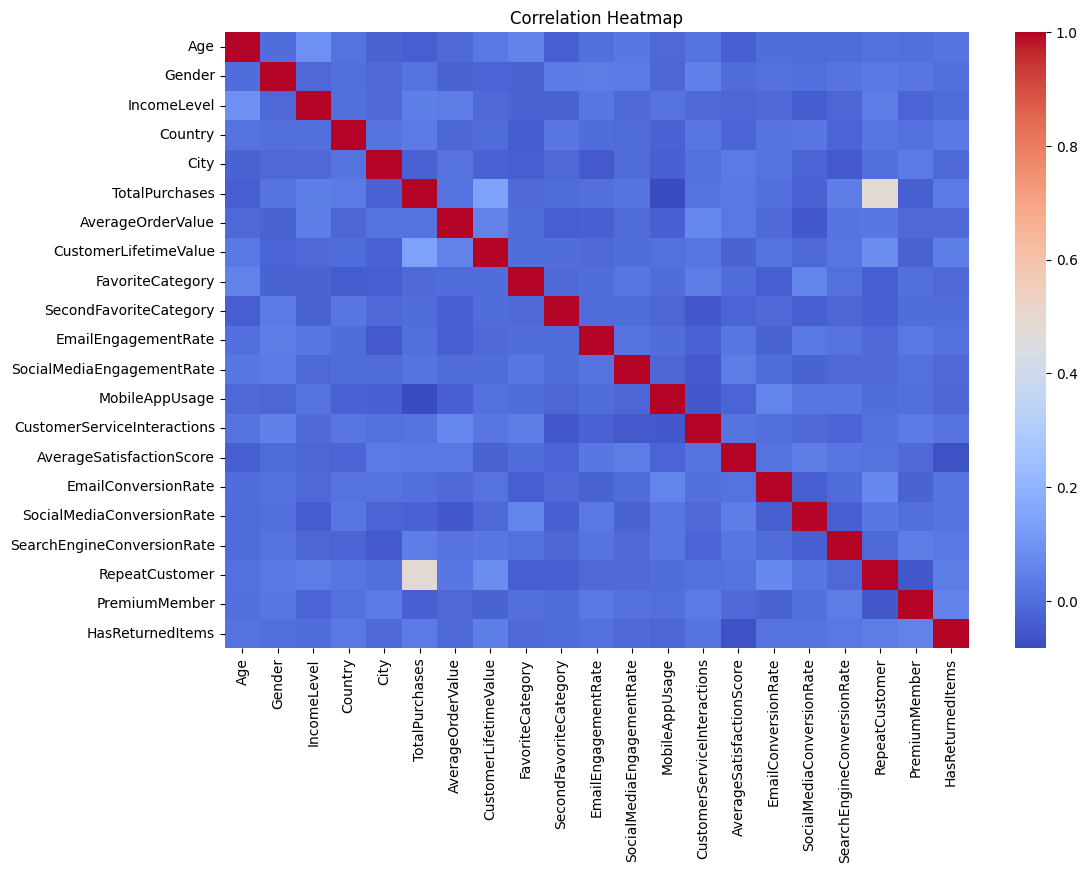

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       226

    accuracy                           1.00       253
   macro avg       1.00      1.00      1.00       253
weighted avg       1.00      1.00      1.00       253

Sample Prediction: [1]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("ecommerce_customer_data.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# -------------------------------
# 2. Data Cleaning
# -------------------------------

# Drop unnecessary columns
df = df.drop(['CustomerID', 'RegistrationDate'], axis=1, errors='ignore')

# Remove missing values
df = df.dropna()

# -------------------------------
# 3. Encode Categorical Data
# -------------------------------

# Convert Yes/No columns
binary_cols = ['RepeatCustomer', 'PremiumMember', 'HasReturnedItems']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Encode remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# -------------------------------
# 4. Visualization
# -------------------------------

if 'AverageOrderValue' in df.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df['AverageOrderValue'])
    plt.title("Boxplot - Average Order Value")
    plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 5. Define Features & Target
# -------------------------------

target = 'RepeatCustomer'  # you can change this

X = df.drop(target, axis=1)
y = df[target]

# -------------------------------
# 6. Feature Scaling
# -------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------------
# 7. Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 8. Train Model
# -------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -------------------------------
# 9. Prediction & Evaluation
# -------------------------------

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -------------------------------
# 10. Single Prediction
# -------------------------------

sample = X_test[0].reshape(1, -1)
print("Sample Prediction:", model.predict(sample))
